# Module B — Crop Yield Prediction

**Dataset** : Indian Crop Yield Dataset (Ramesh V., VIT, 2025 — Mendeley, CC BY 4.0)  
**Records** : 19,689 annual records · 55 crops · 30 Indian states · 1997–2020  
**Features** : Annual Rainfall (mm), Area (ha), Fertilizer (kg), Pesticide (kg), Season, State, Crop, Year  
**Target**   : Yield (tonnes/ha) — pre-computed in dataset, corrected for unit anomalies  

**Research Question RQ2**: What predictive accuracy can ensemble ML models (XGBoost, Random Forest,  
Gradient Boosting) achieve for Indian crop yield estimation when multiple feature types — climate,  
soil, fertiliser and pesticide data — are incorporated?  

**Thesis target** : R² ≥ 0.80 on held-out test set  

---

### Notebook Structure
1. Environment Setup  
2. Dataset Load & Validation  
3. Data Cleaning & Unit Correction  
4. Exploratory Data Analysis (EDA)  
5. Preprocessing Pipeline  
6. Model Training (XGBoost · Random Forest · HistGradientBoosting)  
7. Evaluation (R² · RMSE · MAE)  
8. SHAP Feature Importance  
9. Ablation Study — Full vs Minimal Features  
10. Learning Curves  
11. Final Summary  

### 1. Environment Setup

In [ ]:
import os, warnings, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})

PALETTE = {
    'primary'  : '#1565c0',
    'secondary': '#e65100',
    'neutral'  : '#607d8b',
    'accent'   : '#2e7d32',
    'warn'     : '#f57f17',
}

print('Libraries loaded.')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')

import joblib
import json
import shutil
ARTIFACT_ROOT = 'artifacts/yield'
os.makedirs(ARTIFACT_ROOT, exist_ok=True)
print(f'\nArtifact checkpoints will be written to: {os.path.abspath(ARTIFACT_ROOT)}')

Libraries loaded.
pandas  2.2.2
numpy   2.0.2

Artifact checkpoints will be written to: /content/artifacts/yield


### 2. Dataset Load & Validation

Dataset uploaded directly from Mendeley (CC BY 4.0).  
Upload `crop_yield.csv` to your Colab session via the file panel before running.


In [ ]:
# Upload via Colab file panel OR mount Drive
# Option A — direct upload (simplest)
from google.colab import files
uploaded = files.upload()   # select crop_yield.csv
DATASET_PATH = list(uploaded.keys())[0]

# Option B — if already uploaded / running locally
DATASET_PATH = 'crop_yield.csv'

df_raw = pd.read_csv(DATASET_PATH)

print('Raw Dataset')
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')
print(f'\n  Columns : {df_raw.columns.tolist()}')
print(f'\n  dtypes:')
print(df_raw.dtypes)
print(f'\n  Head:')
print(df_raw.head(3))

# Normalise strings
df_raw['Crop']   = df_raw['Crop'].str.strip()
df_raw['Season'] = df_raw['Season'].str.strip()
df_raw['State']  = df_raw['State'].str.strip()

print(f'\n  Missing values:')
print(df_raw.isnull().sum())

Saving crop_yield.csv to crop_yield.csv
Raw Dataset
  Rows    : 19,689
  Columns : 10

  Columns : ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

  dtypes:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

  Head:
          Crop  Crop_Year       Season  State     Area  Production  \
0     Arecanut       1997  Whole Year   Assam  73814.0       56708   
1    Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2  Castor seed       1997  Kharif       Assam    796.0          22   

   Annual_Rainfall  Fertilizer  Pesticide     Yield  
0           2051.4  7024878.38   22882.34  0.796087  
1           2051.4   631643.29    2057.47  0.710435  
2           2051.4    75755.32     2

### 3. Data Cleaning & Unit Correction

Two unit issues exist in this dataset:

1. **Coconut Yield** is stored in nuts/hectare, not tonnes/hectare.  
   Average coconut weight ≈ 1.5 kg → multiply by 0.0015 to convert to tonnes/ha.

2. **Fertilizer & Pesticide** are stored as **total kg** (for the entire cultivated area),  
   not per hectare. Divide by Area to get kg/ha — the agronomically meaningful unit.

After corrections, cap per-crop outliers at the 99.5th percentile to remove  
data entry errors without dropping entire crop categories.

In [ ]:
df = df_raw.copy()

print('Before cleaning:')
print(f'  Yield max    : {df["Yield"].max():,.2f}')
print(f'  Yield median : {df["Yield"].median():.2f}')
print(f'  Rows         : {len(df):,}')

# Fix 1: Coconut unit conversion (nuts/ha → tonnes/ha)
COCONUT_KG_PER_NUT = 0.0015
coconut_mask = df['Crop'] == 'Coconut'
df.loc[coconut_mask, 'Yield'] = df.loc[coconut_mask, 'Yield'] * COCONUT_KG_PER_NUT
print(f'\n  Coconut rows converted : {coconut_mask.sum()}')
print(f'  Coconut yield after    : {df.loc[coconut_mask, "Yield"].describe().round(3)}')

# Fix 2: Derive Fertilizer & Pesticide per hectare
df['Fertilizer_per_ha'] = df['Fertilizer'] / df['Area']
df['Pesticide_per_ha']  = df['Pesticide']  / df['Area']

print(f'\n  Fertilizer_per_ha range: {df["Fertilizer_per_ha"].min():.2f} — {df["Fertilizer_per_ha"].max():.2f} kg/ha')
print(f'  Pesticide_per_ha range : {df["Pesticide_per_ha"].min():.4f} — {df["Pesticide_per_ha"].max():.4f} kg/ha')

# Fix 3: Remove zero/negative yields
before = len(df)
df = df[df['Yield'] > 0].copy()
print(f'\n  Rows removed (Yield <= 0) : {before - len(df)}')

# Fix 4: Per-crop 99.5th percentile cap
cap = df.groupby('Crop')['Yield'].transform(lambda x: x.quantile(0.995))
df['Yield'] = np.minimum(df['Yield'], cap)

# Replace infinities from division
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['Yield', 'Fertilizer_per_ha', 'Pesticide_per_ha'], inplace=True)

print(f'\nAfter cleaning:')
print(f'  Yield max    : {df["Yield"].max():,.2f} tonnes/ha')
print(f'  Yield median : {df["Yield"].median():.2f} tonnes/ha')
print(f'  Rows         : {len(df):,}')
print(f'\n  Yield distribution:')
print(df['Yield'].describe().round(3))

Before cleaning:
  Yield max    : 21,105.00
  Yield median : 1.03
  Rows         : 19,689

  Coconut rows converted : 172
  Coconut yield after    : count    172.000
mean      12.978
std        5.659
min        0.000
25%        8.922
50%       12.699
75%       17.973
max       31.658
Name: Yield, dtype: float64

  Fertilizer_per_ha range: 94.67 — 193.61 kg/ha
  Pesticide_per_ha range : 0.0900 — 0.3800 kg/ha

  Rows removed (Yield <= 0) : 112

After cleaning:
  Yield max    : 156.02 tonnes/ha
  Yield median : 1.04 tonnes/ha
  Rows         : 19,577

  Yield distribution:
count    19577.000
mean         4.369
std         11.642
min          0.004
25%          0.604
50%          1.037
75%          2.397
max        156.025
Name: Yield, dtype: float64


In [ ]:
CLEANED_DATA_PATH = os.path.join(ARTIFACT_ROOT, 'cleaned_dataset.csv')
df.to_csv(CLEANED_DATA_PATH, index=False)
print(f'Checkpoint saved: {CLEANED_DATA_PATH}  ({len(df):,} rows)')

Checkpoint saved: artifacts/yield/cleaned_dataset.csv  (19,577 rows)


### 4. Exploratory Data Analysis (EDA)


4.1 Missing Values
  No missing values.


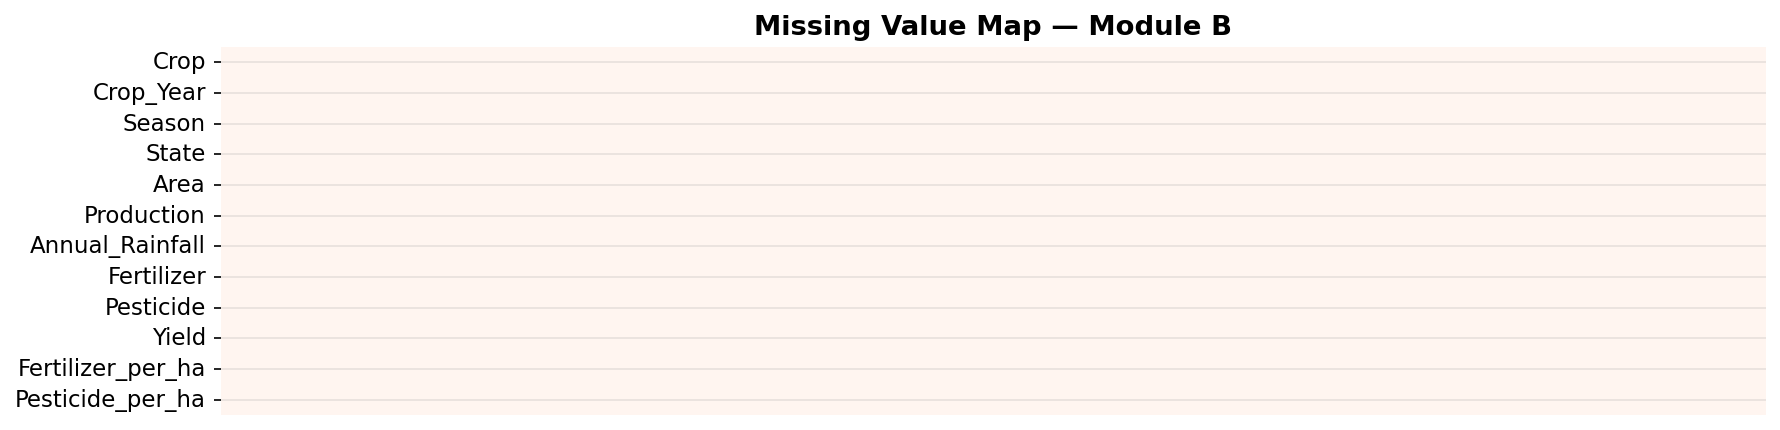

In [ ]:
# 4.1 Missing Value Heatmap
print('4.1 Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '  No missing values.')

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df.isnull().astype(int).T, cmap='Reds', cbar=False,
            xticklabels=False, ax=ax)
ax.set_title('Missing Value Map — Module B', fontweight='bold')
plt.tight_layout()
plt.show()

4.2 Yield Distribution
count    19577.000
mean         4.369
std         11.642
min          0.004
25%          0.604
50%          1.037
75%          2.397
max        156.025
Name: Yield, dtype: float64


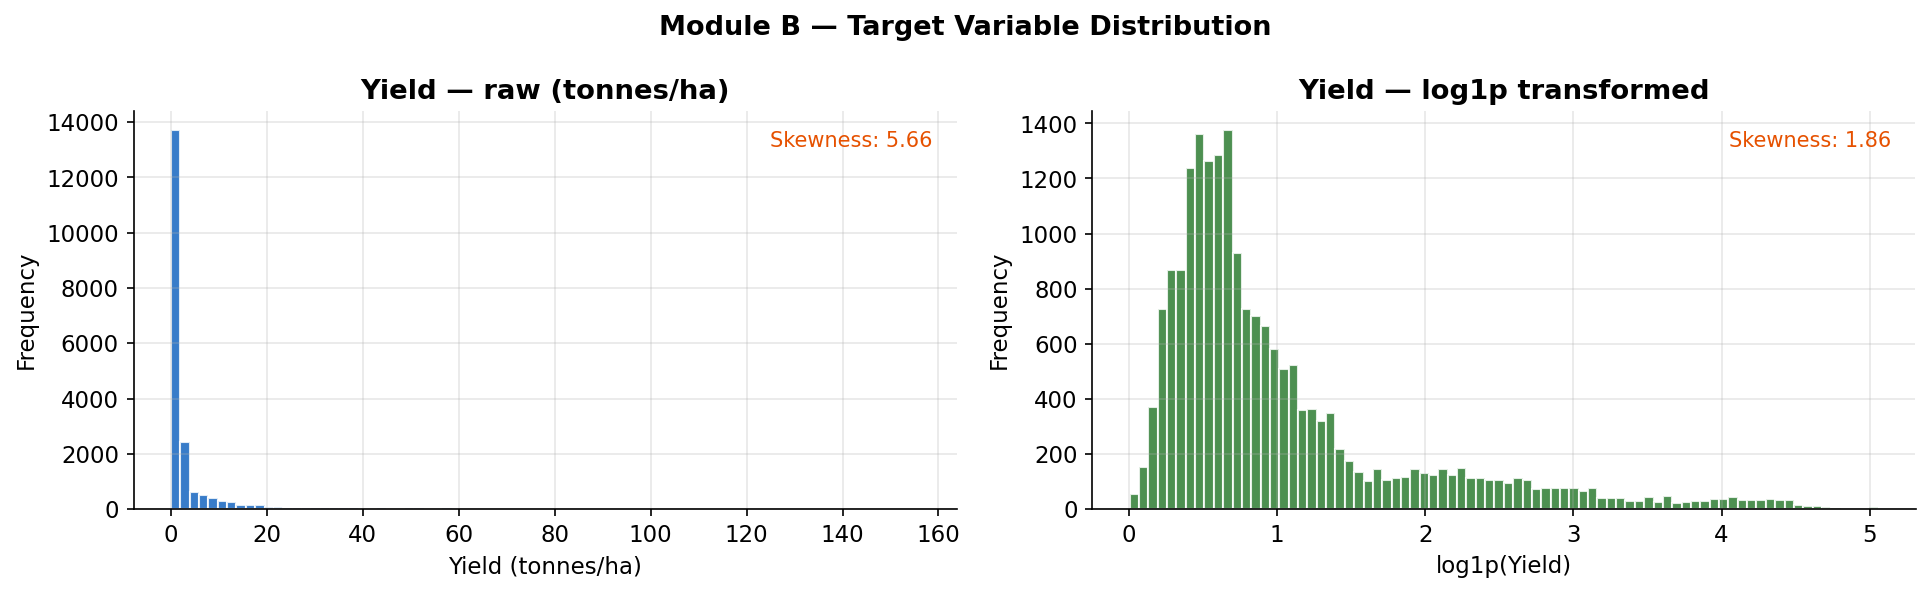

In [ ]:
# 4.2 Target Variable Distribution
print('4.2 Yield Distribution')
print(df['Yield'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Yield'], bins=80, color=PALETTE['primary'],
             edgecolor='white', alpha=0.85)
axes[0].set_title('Yield — raw (tonnes/ha)', fontweight='bold')
axes[0].set_xlabel('Yield (tonnes/ha)')
axes[0].set_ylabel('Frequency')
axes[0].text(0.97, 0.95, f'Skewness: {df["Yield"].skew():.2f}',
             transform=axes[0].transAxes, ha='right', va='top',
             color=PALETTE['secondary'], fontsize=10)

log_yield = np.log1p(df['Yield'])
axes[1].hist(log_yield, bins=80, color=PALETTE['accent'],
             edgecolor='white', alpha=0.85)
axes[1].set_title('Yield — log1p transformed', fontweight='bold')
axes[1].set_xlabel('log1p(Yield)')
axes[1].set_ylabel('Frequency')
axes[1].text(0.97, 0.95, f'Skewness: {log_yield.skew():.2f}',
             transform=axes[1].transAxes, ha='right', va='top',
             color=PALETTE['secondary'], fontsize=10)

plt.suptitle('Module B — Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 4.3 Categorical Cardinality
print('4.3 Categorical Cardinality')
for col in ['State', 'Crop', 'Season']:
    print(f'\n  {col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(5).to_string())

4.3 Categorical Cardinality

  State: 30 unique values
State
Karnataka         1430
Andhra Pradesh    1253
West Bengal       1092
Bihar              896
Chhattisgarh       893

  Crop: 55 unique values
Crop
Rice                 1197
Maize                 974
Moong(Green Gram)     734
Urad                  730
Groundnut             725

  Season: 6 unique values
Season
Kharif        8183
Rabi          5732
Whole Year    3666
Summer        1193
Autumn         414


4.4 Top 15 Crops
             Crop  Count  Mean_Yield  Std_Yield
             Rice   1197        2.21       0.78
            Maize    974        2.44       2.10
Moong(Green Gram)    734        0.53       0.24
             Urad    730        0.58       0.27
        Groundnut    725        1.36       0.62
          Sesamum    684        0.47       0.23
           Potato    627       12.12       6.44
        Sugarcane    605       51.69      30.48
            Wheat    543        2.01       1.07
Rapeseed &Mustard    528        0.78       0.47
            Bajra    524        2.36       6.01
            Jowar    513        1.07       0.51
        Arhar/Tur    508        0.84       0.34
             Ragi    498        1.21       0.68
             Gram    489        0.86       0.33


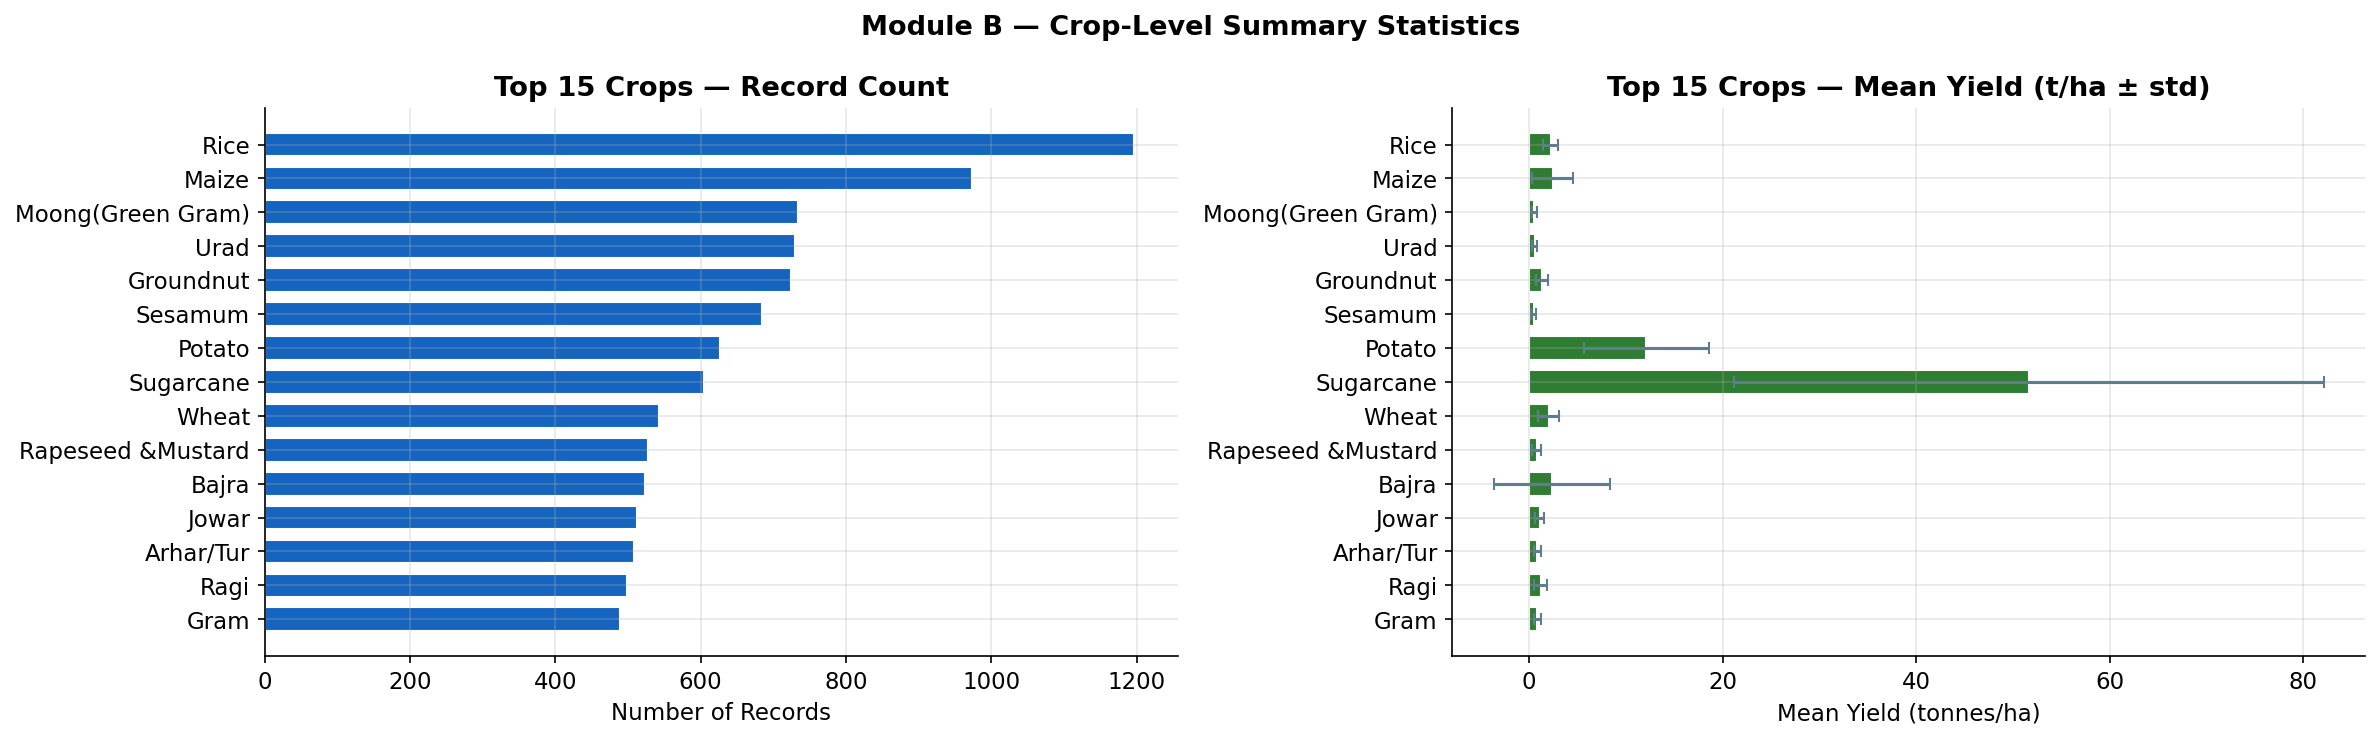

In [ ]:
# 4.4 Top 15 Crops — Record Count & Mean Yield
print('4.4 Top 15 Crops')
crop_stats = (df.groupby('Crop')
              .agg(Count=('Yield','count'),
                   Mean_Yield=('Yield','mean'),
                   Std_Yield=('Yield','std'))
              .sort_values('Count', ascending=False)
              .head(15).reset_index())
print(crop_stats.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(crop_stats['Crop'][::-1], crop_stats['Count'][::-1],
             color=PALETTE['primary'], edgecolor='white', height=0.7)
axes[0].set_title('Top 15 Crops — Record Count', fontweight='bold')
axes[0].set_xlabel('Number of Records')

axes[1].barh(crop_stats['Crop'][::-1], crop_stats['Mean_Yield'][::-1],
             xerr=crop_stats['Std_Yield'][::-1],
             color=PALETTE['accent'], edgecolor='white', height=0.7,
             error_kw={'ecolor': PALETTE['neutral'], 'capsize': 3})
axes[1].set_title('Top 15 Crops — Mean Yield (t/ha ± std)', fontweight='bold')
axes[1].set_xlabel('Mean Yield (tonnes/ha)')

plt.suptitle('Module B — Crop-Level Summary Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

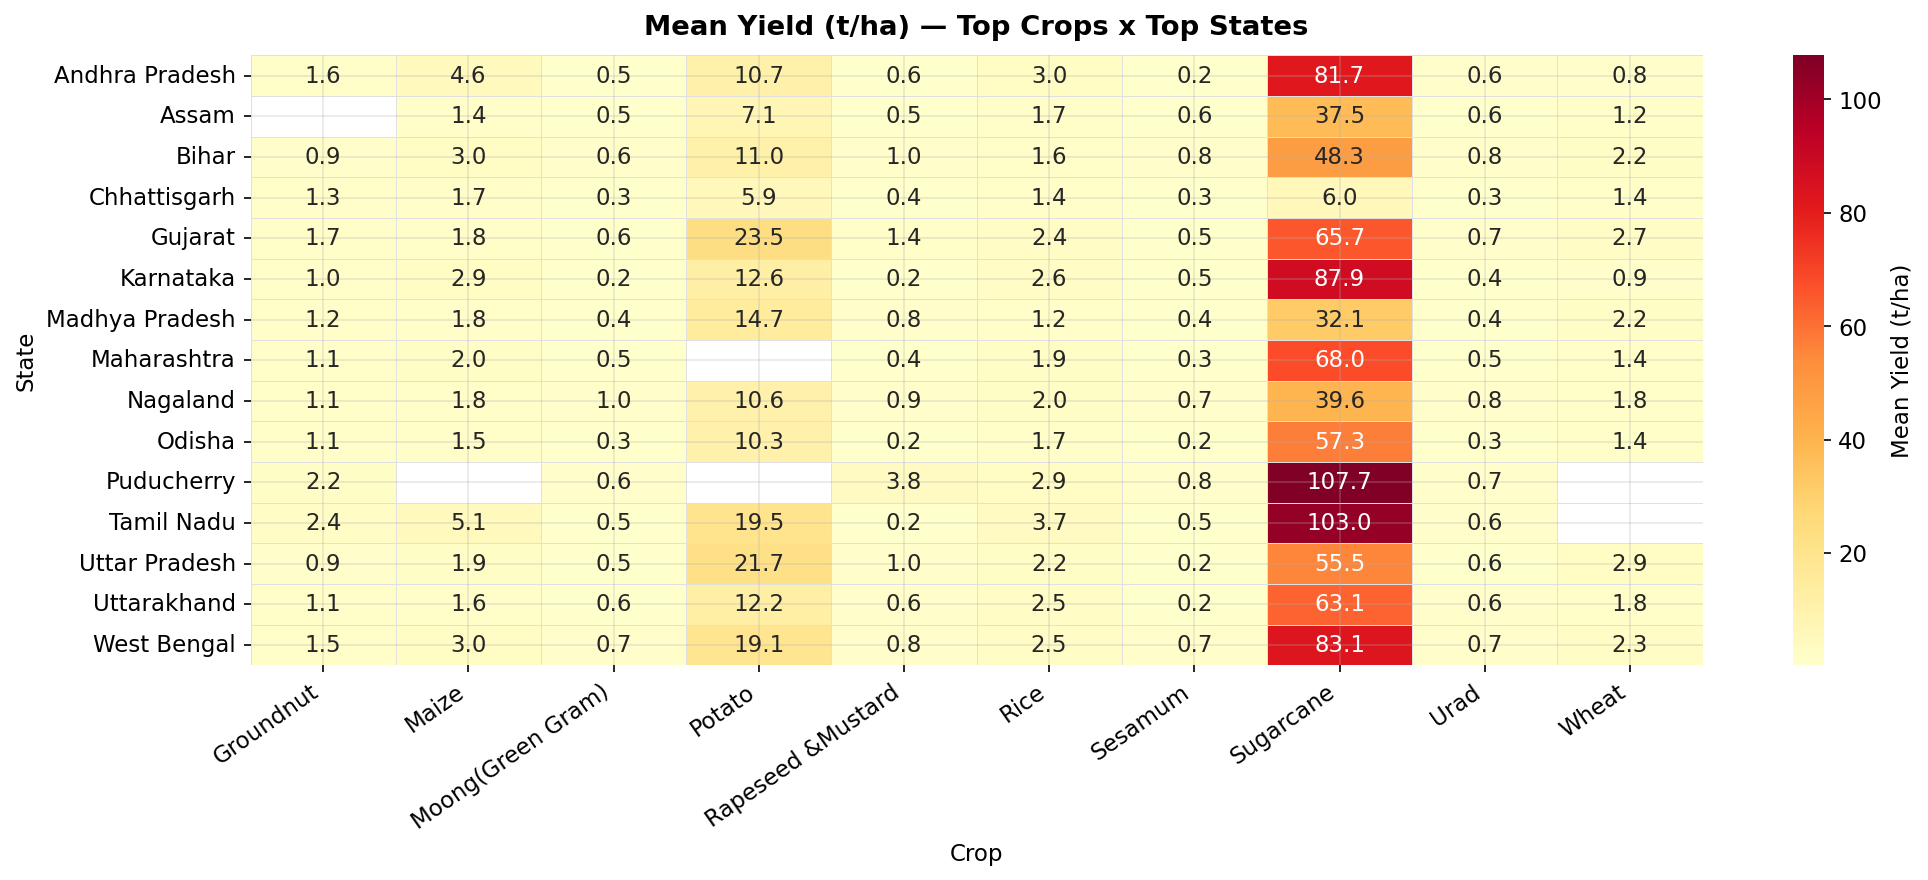

In [ ]:
# 4.5 State × Crop Mean Yield Heatmap
top_crops  = df['Crop'].value_counts().head(10).index.tolist()
top_states = df['State'].value_counts().head(15).index.tolist()

hmap_df = (df[df['Crop'].isin(top_crops) & df['State'].isin(top_states)]
           .groupby(['State','Crop'])['Yield'].mean()
           .unstack(fill_value=np.nan))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(hmap_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='#e0e0e0',
            cbar_kws={'label': 'Mean Yield (t/ha)'}, ax=ax)
ax.set_title('Mean Yield (t/ha) — Top Crops x Top States', fontweight='bold', pad=10)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

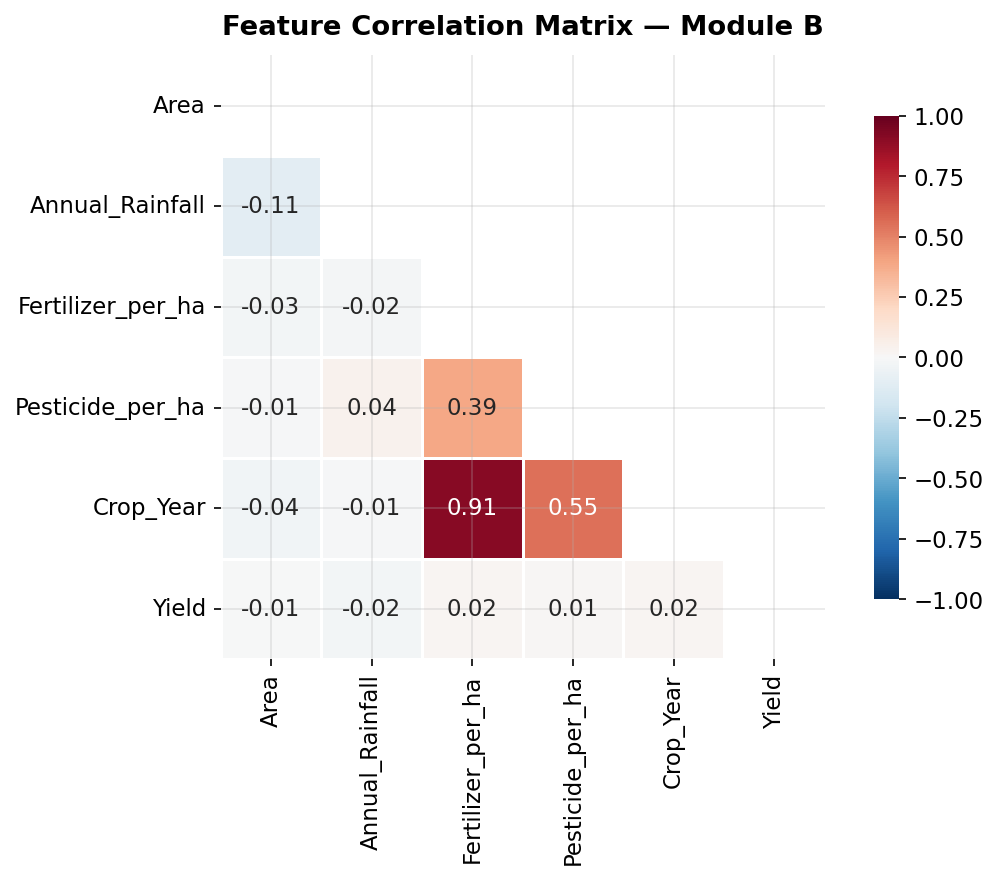

In [ ]:
# 4.6 Feature Correlation Matrix
num_cols = ['Area', 'Annual_Rainfall', 'Fertilizer_per_ha', 'Pesticide_per_ha',
            'Crop_Year', 'Yield']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix — Module B', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

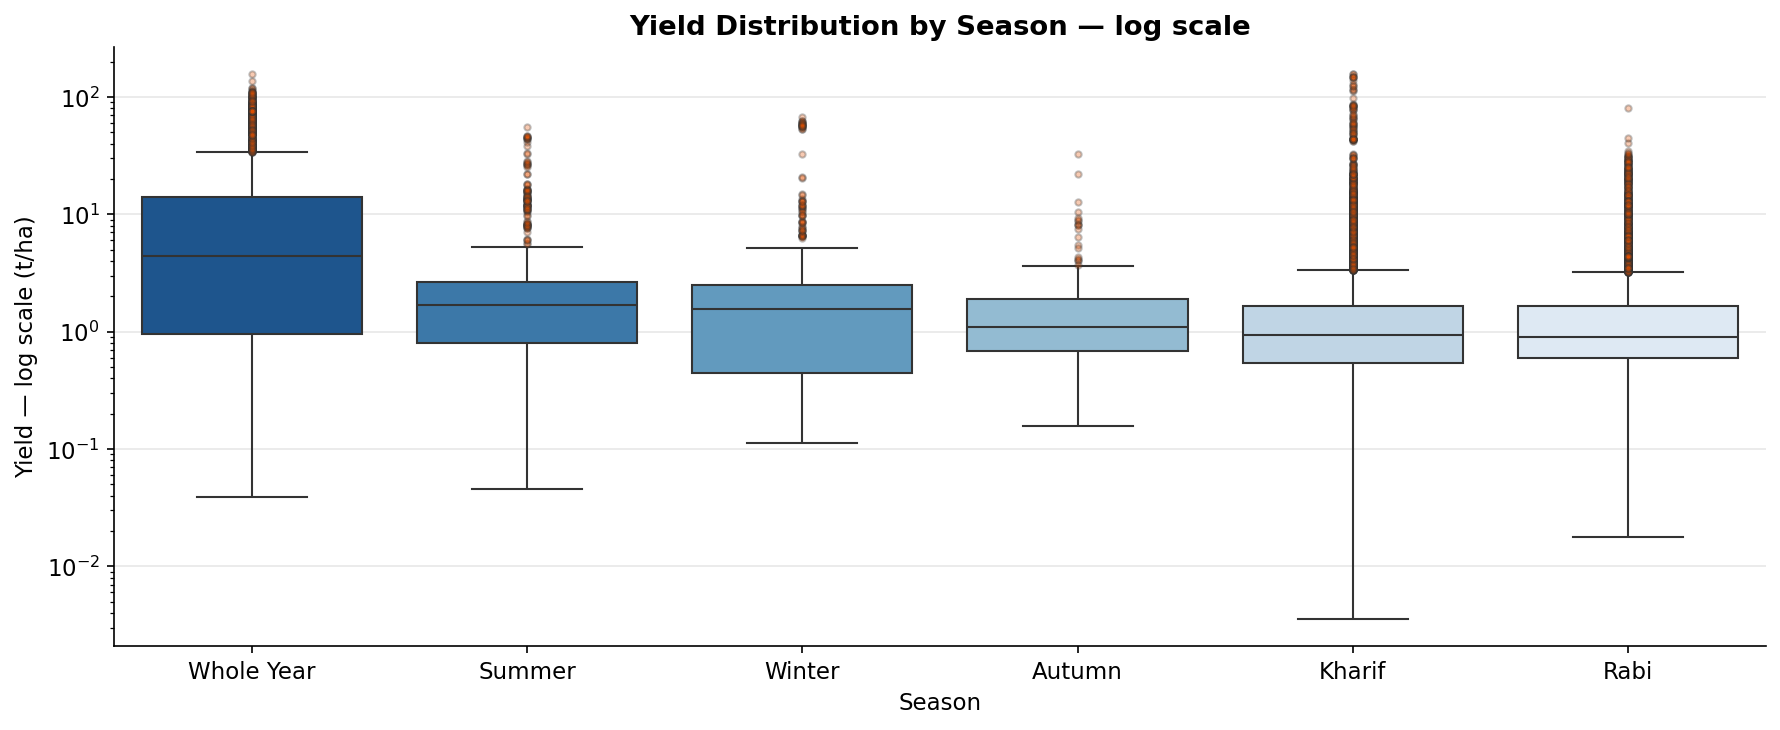

In [ ]:
# 4.7 Yield Distribution by Season
fig, ax = plt.subplots(figsize=(12, 5))
season_order = (df.groupby('Season')['Yield'].median()
                .sort_values(ascending=False).index.tolist())
sns.boxplot(data=df, x='Season', y='Yield', order=season_order,
            palette='Blues_r',
            flierprops={'marker':'.','alpha':0.3,
                        'markerfacecolor': PALETTE['secondary']},
            ax=ax)
ax.set_yscale('log')
ax.set_title('Yield Distribution by Season — log scale', fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Yield — log scale (t/ha)')
plt.tight_layout()
plt.show()

In [ ]:
# 4.8 EDA Summary
print('\n\u2550\u2550 MODULE B \u2014 EDA SUMMARY \u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550')
print(f'  Total records         : {len(df):,}')
print(f'  Unique crops          : {df["Crop"].nunique()}')
print(f'  Unique states         : {df["State"].nunique()}')
print(f'  Unique seasons        : {df["Season"].nunique()}')
print(f'  Year range            : {df["Crop_Year"].min()} \u2013 {df["Crop_Year"].max()}')
print(f'  Yield median          : {df["Yield"].median():.3f} t/ha')
print(f'  Yield mean            : {df["Yield"].mean():.3f} t/ha')
print(f'  Yield max             : {df["Yield"].max():.3f} t/ha')
print(f'  Skewness raw          : {df["Yield"].skew():.2f}')
print(f'  Skewness log1p        : {np.log1p(df["Yield"]).skew():.2f}')
print(f'  Missing values        : 0')
print('\n  EDA complete. Ready for preprocessing.')


══ MODULE B — EDA SUMMARY ════════════════════════
  Total records         : 19,577
  Unique crops          : 55
  Unique states         : 30
  Unique seasons        : 6
  Year range            : 1997 – 2020
  Yield median          : 1.037 t/ha
  Yield mean            : 4.369 t/ha
  Yield max             : 156.025 t/ha
  Skewness raw          : 5.66
  Skewness log1p        : 1.86
  Missing values        : 0

  EDA complete. Ready for preprocessing.


### 5. Preprocessing Pipeline

**Full feature set** (RQ2 — multi-feature):  
`Annual_Rainfall`, `Area`, `Fertilizer_per_ha`, `Pesticide_per_ha`, `Crop_Year` + `State`, `Crop`, `Season`  

**Minimal feature set** (ablation baseline):  
`Annual_Rainfall`, `Area` + `State`, `Crop`, `Season`  

Pipeline: KNN imputation → StandardScaler (numeric) · OneHotEncoder (categorical)  
Split: 80% train · 10% val · 10% test — stratified by Crop

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Feature configuration
NUMERIC_FEATURES_FULL = ['Annual_Rainfall', 'Area', 'Fertilizer_per_ha',
                          'Pesticide_per_ha', 'Crop_Year']
NUMERIC_FEATURES_MIN  = ['Annual_Rainfall', 'Area']
CATEGORICAL_FEATURES  = ['State', 'Crop', 'Season']
TARGET                = 'Yield'

features_full = NUMERIC_FEATURES_FULL + CATEGORICAL_FEATURES
features_min  = NUMERIC_FEATURES_MIN  + CATEGORICAL_FEATURES

print(f'Numeric (full) : {NUMERIC_FEATURES_FULL}')
print(f'Numeric (min)  : {NUMERIC_FEATURES_MIN}')
print(f'Categorical    : {CATEGORICAL_FEATURES}')
print(f'Target         : {TARGET}')

# Train / Val / Test split (80 / 10 / 10) stratified by Crop
X = df[features_full + [f for f in features_min if f not in features_full]]
y = df[TARGET]

X_tv, X_test, y_tv, y_test = train_test_split(
    df, y, test_size=0.10, random_state=RANDOM_STATE, stratify=df['Crop'])
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, random_state=RANDOM_STATE,
    stratify=X_tv['Crop'])
X_test_df = X_test

print(f'Train : {len(X_train_df):,}  ({100*len(X_train_df)/len(df):.1f}%)')
print(f'Val   : {len(X_val_df):,}   ({100*len(X_val_df)/len(df):.1f}%)')
print(f'Test  : {len(X_test_df):,}   ({100*len(X_test_df)/len(df):.1f}%)')
print(f'\nCrops in train : {X_train_df["Crop"].nunique()}')
print(f'Crops in test  : {X_test_df["Crop"].nunique()}')

# Build & fit ColumnTransformer pipelines
def build_preprocessor(num_feats, cat_feats):
    num_pipe = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_feats),
        ('cat', cat_pipe, cat_feats),
    ], remainder='drop', verbose_feature_names_out=False)

preprocessor_full = build_preprocessor(NUMERIC_FEATURES_FULL, CATEGORICAL_FEATURES)
preprocessor_min  = build_preprocessor(NUMERIC_FEATURES_MIN,  CATEGORICAL_FEATURES)

# Fit on train, transform all splits
X_full_train_pp = preprocessor_full.fit_transform(X_train_df[features_full])
X_full_val_pp   = preprocessor_full.transform(X_val_df[features_full])
X_full_test_pp  = preprocessor_full.transform(X_test_df[features_full])

X_min_train_pp  = preprocessor_min.fit_transform(X_train_df[features_min])
X_min_val_pp    = preprocessor_min.transform(X_val_df[features_min])
X_min_test_pp   = preprocessor_min.transform(X_test_df[features_min])

print(f'Full — train: {X_full_train_pp.shape}  val: {X_full_val_pp.shape}  test: {X_full_test_pp.shape}')
print(f'Min  — train: {X_min_train_pp.shape}  val: {X_min_val_pp.shape}  test: {X_min_test_pp.shape}')

# Stratified 20% GS subsample (by Crop)
df_train_full = X_train_df.copy()

df_gs = (df_train_full
         .groupby('Crop', group_keys=False)
         .apply(lambda grp: grp.sample(frac=0.20, random_state=RANDOM_STATE)))

X_full_gs = preprocessor_full.transform(df_gs[features_full])
X_min_gs  = preprocessor_min.transform(df_gs[features_min])
y_gs      = np.log1p(df_gs[TARGET].values)

# Log-transform train/val/test targets
y_train_log = np.log1p(y_train.values)
y_val_log   = np.log1p(y_val.values)
y_test_log  = np.log1p(y_test.values)

print(f'GS subset       : {len(df_gs):,} rows (20% stratified by Crop)')
print(f'Crops in GS     : {df_gs["Crop"].nunique()} / {df_train_full["Crop"].nunique()}')
print(f'States in GS    : {df_gs["State"].nunique()} / {df_train_full["State"].nunique()}')
print(f'X_full_gs shape : {X_full_gs.shape}')
print(f'X_min_gs shape  : {X_min_gs.shape}')

Numeric (full) : ['Annual_Rainfall', 'Area', 'Fertilizer_per_ha', 'Pesticide_per_ha', 'Crop_Year']
Numeric (min)  : ['Annual_Rainfall', 'Area']
Categorical    : ['State', 'Crop', 'Season']
Target         : Yield
Train : 15,663  (80.0%)
Val   : 1,956   (10.0%)
Test  : 1,958   (10.0%)

Crops in train : 55
Crops in test  : 55
Full — train: (15663, 96)  val: (1956, 96)  test: (1958, 96)
Min  — train: (15663, 93)  val: (1956, 93)  test: (1958, 93)
GS subset       : 3,134 rows (20% stratified by Crop)
Crops in GS     : 55 / 55
States in GS    : 30 / 30
X_full_gs shape : (3134, 96)
X_min_gs shape  : (3134, 93)


In [ ]:
joblib.dump(preprocessor_full, os.path.join(ARTIFACT_ROOT, 'preprocessor_full.pkl'))
joblib.dump(preprocessor_min,  os.path.join(ARTIFACT_ROOT, 'preprocessor_min.pkl'))

X_train_df.to_csv(os.path.join(ARTIFACT_ROOT, 'train_split.csv'), index=False)
X_val_df.to_csv(os.path.join(ARTIFACT_ROOT, 'val_split.csv'), index=False)
X_test_df.to_csv(os.path.join(ARTIFACT_ROOT, 'test_split.csv'), index=False)

feature_config = {
    'numeric_features_full': NUMERIC_FEATURES_FULL,
    'numeric_features_min':  NUMERIC_FEATURES_MIN,
    'categorical_features':  CATEGORICAL_FEATURES,
    'target':                TARGET,
    'target_transform':      'log1p',   # models are trained on np.log1p(Yield)
    'inverse_transform':     'expm1',   # apply np.expm1 to predictions, then clip at 0
    'random_state':          RANDOM_STATE,
}
with open(os.path.join(ARTIFACT_ROOT, 'feature_config.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)

print('Checkpoint saved:')
print(f'  {ARTIFACT_ROOT}/preprocessor_full.pkl')
print(f'  {ARTIFACT_ROOT}/preprocessor_min.pkl')
print(f'  {ARTIFACT_ROOT}/train_split.csv  ({len(X_train_df):,} rows)')
print(f'  {ARTIFACT_ROOT}/val_split.csv    ({len(X_val_df):,} rows)')
print(f'  {ARTIFACT_ROOT}/test_split.csv   ({len(X_test_df):,} rows)')
print(f'  {ARTIFACT_ROOT}/feature_config.json')

Checkpoint saved:
  artifacts/yield/preprocessor_full.pkl
  artifacts/yield/preprocessor_min.pkl
  artifacts/yield/train_split.csv  (15,663 rows)
  artifacts/yield/val_split.csv    (1,956 rows)
  artifacts/yield/test_split.csv   (1,958 rows)
  artifacts/yield/feature_config.json


### 6. Model Training

Three ensemble algorithms per the research design (RQ2):  
- **XGBoost** — histogram-based gradient boosting (GPU-accelerated if available)  
- **Random Forest** — fully parallelised bagging  
- **HistGradientBoosting** — sklearn's fast histogram boosting (10–20x faster than GBT)  

Strategy: manual grid search with `cross_val_score` on the 20% stratified subsample  
→ prints each config result live → retrain best config on full training set.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import xgboost as xgb
import subprocess

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Detect GPU
try:
    subprocess.check_output('nvidia-smi')
    DEVICE = 'cuda'
    print('GPU detected — XGBoost will use device=cuda')
except Exception:
    DEVICE = 'cpu'
    print('No GPU detected — using CPU')

print('Imports ready.')
print(f'Train size   : {X_full_train_pp.shape[0]:,} rows x {X_full_train_pp.shape[1]} features (full)')
print(f'GS subset    : {X_full_gs.shape[0]:,} rows  (20% stratified by Crop)')
print(f'Val size     : {X_full_val_pp.shape[0]:,} rows')
print(f'Test size    : {X_full_test_pp.shape[0]:,} rows')

GPU detected — XGBoost will use device=cuda
Imports ready.
Train size   : 15,663 rows x 96 features (full)
GS subset    : 3,134 rows  (20% stratified by Crop)
Val size     : 1,956 rows
Test size    : 1,958 rows


#### 6.1  XGBoost

In [ ]:
# 6.1  XGBoost
xgb_param_grid = {
    'n_estimators' : [300, 500],
    'max_depth'    : [6, 8],
    'learning_rate': [0.05, 0.10],
}
keys_xgb   = list(xgb_param_grid.keys())
combos_xgb = list(product(*xgb_param_grid.values()))

def run_grid(combos, keys, model_fn, X_gs, label):
    best_score, best_params = -np.inf, {}
    total = len(combos)
    print(f'\n\u2500\u2500 {label} ({total} configs x 3 folds = {total*3} fits) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
    for i, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo))
        model  = model_fn(params)
        t0     = time.time()
        scores = cross_val_score(model, X_gs, y_gs, cv=kf, scoring='r2', n_jobs=-1)
        elapsed = time.time() - t0
        mean_r2 = scores.mean()
        print(f'  [{i:02d}/{total}] {params}')
        print(f'         CV R2: {mean_r2:.4f} (+-{scores.std():.4f})  time: {elapsed:.1f}s')
        if mean_r2 > best_score:
            best_score, best_params = mean_r2, params
    print(f'\n  Best params : {best_params}')
    print(f'  Best CV R2  : {best_score:.4f}')
    return best_params, best_score

# Full features
xgb_fn_full = lambda p: xgb.XGBRegressor(
    objective='reg:squarederror', random_state=RANDOM_STATE,
    tree_method='hist', device=DEVICE,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1, **p)

xgb_best_full, _ = run_grid(combos_xgb, keys_xgb, xgb_fn_full,
                             X_full_gs, 'XGBoost (full features)')

print('\n  Retraining on full training set...')
t0 = time.time()
xgb_full = xgb.XGBRegressor(
    objective='reg:squarederror', random_state=RANDOM_STATE,
    tree_method='hist', device=DEVICE,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
    **xgb_best_full)
xgb_full.fit(X_full_train_pp, y_train_log,
             eval_set=[(X_full_val_pp, y_val_log)],
             verbose=50)
print(f'  Done in {time.time()-t0:.1f}s')

# Minimal features
xgb_fn_min = lambda p: xgb.XGBRegressor(
    objective='reg:squarederror', random_state=RANDOM_STATE,
    tree_method='hist', device=DEVICE,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1, **p)

xgb_best_min, _ = run_grid(combos_xgb, keys_xgb, xgb_fn_min,
                            X_min_gs, 'XGBoost (minimal features)')

t0 = time.time()
xgb_min = xgb.XGBRegressor(
    objective='reg:squarederror', random_state=RANDOM_STATE,
    tree_method='hist', device=DEVICE,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
    **xgb_best_min)
xgb_min.fit(X_min_train_pp, y_train_log)
print(f'  Done in {time.time()-t0:.1f}s')


── XGBoost (full features) (8 configs x 3 folds = 24 fits) ──────────
  [01/8] {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
         CV R2: 0.8767 (+-0.0093)  time: 5.2s
  [02/8] {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
         CV R2: 0.8864 (+-0.0099)  time: 2.3s
  [03/8] {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05}
         CV R2: 0.8826 (+-0.0104)  time: 3.0s
  [04/8] {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}
         CV R2: 0.8864 (+-0.0121)  time: 2.6s
  [05/8] {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05}
         CV R2: 0.8882 (+-0.0086)  time: 3.3s
  [06/8] {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1}
         CV R2: 0.8888 (+-0.0095)  time: 3.7s
  [07/8] {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05}
         CV R2: 0.8890 (+-0.0098)  time: 5.2s
  [08/8] {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1}
         CV R2: 0.8870 (+-0.0116)  time: 4.4s

  Be

#### 6.2  Random Forest

In [ ]:
# 6.2  Random Forest
rf_param_grid = {
    'n_estimators' : [200, 400],
    'max_depth'    : [20, 40],
    'max_features' : ['sqrt', 0.3],
}
keys_rf   = list(rf_param_grid.keys())
combos_rf = list(product(*rf_param_grid.values()))

rf_fn_full = lambda p: RandomForestRegressor(
    random_state=RANDOM_STATE, min_samples_leaf=3, n_jobs=-1, **p)

rf_best_full, _ = run_grid(combos_rf, keys_rf, rf_fn_full,
                            X_full_gs, 'Random Forest (full features)')

print('\n  Retraining on full training set...')
t0 = time.time()
rf_full = RandomForestRegressor(
    random_state=RANDOM_STATE, min_samples_leaf=3, n_jobs=-1,
    **rf_best_full)
rf_full.fit(X_full_train_pp, y_train_log)
print(f'  Done in {time.time()-t0:.1f}s')

rf_fn_min = lambda p: RandomForestRegressor(
    random_state=RANDOM_STATE, min_samples_leaf=3, n_jobs=-1, **p)

rf_best_min, _ = run_grid(combos_rf, keys_rf, rf_fn_min,
                           X_min_gs, 'Random Forest (minimal features)')

t0 = time.time()
rf_min = RandomForestRegressor(
    random_state=RANDOM_STATE, min_samples_leaf=3, n_jobs=-1,
    **rf_best_min)
rf_min.fit(X_min_train_pp, y_train_log)
print(f'  Done in {time.time()-t0:.1f}s')


── Random Forest (full features) (8 configs x 3 folds = 24 fits) ──────────
  [01/8] {'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt'}
         CV R2: 0.7244 (+-0.0229)  time: 1.7s
  [02/8] {'n_estimators': 200, 'max_depth': 20, 'max_features': 0.3}
         CV R2: 0.8067 (+-0.0149)  time: 3.8s
  [03/8] {'n_estimators': 200, 'max_depth': 40, 'max_features': 'sqrt'}
         CV R2: 0.7442 (+-0.0207)  time: 2.1s
  [04/8] {'n_estimators': 200, 'max_depth': 40, 'max_features': 0.3}
         CV R2: 0.8145 (+-0.0157)  time: 3.6s
  [05/8] {'n_estimators': 400, 'max_depth': 20, 'max_features': 'sqrt'}
         CV R2: 0.7235 (+-0.0240)  time: 3.0s
  [06/8] {'n_estimators': 400, 'max_depth': 20, 'max_features': 0.3}
         CV R2: 0.8057 (+-0.0153)  time: 6.9s
  [07/8] {'n_estimators': 400, 'max_depth': 40, 'max_features': 'sqrt'}
         CV R2: 0.7407 (+-0.0241)  time: 3.4s
  [08/8] {'n_estimators': 400, 'max_depth': 40, 'max_features': 0.3}
         CV R2: 0.8135 (+-0.0161)  ti

#### 6.3  HistGradientBoosting

In [ ]:
# 6.3  HistGradientBoosting
gb_param_grid = {
    'max_iter'     : [300, 500],
    'max_depth'    : [5, 7],
    'learning_rate': [0.05, 0.10],
}
keys_gb   = list(gb_param_grid.keys())
combos_gb = list(product(*gb_param_grid.values()))

gb_fn_full = lambda p: HistGradientBoostingRegressor(
    random_state=RANDOM_STATE, early_stopping=False, **p)

gb_best_full, _ = run_grid(combos_gb, keys_gb, gb_fn_full,
                            X_full_gs, 'HistGradientBoosting (full features)')

print('\n  Retraining on full training set...')
t0 = time.time()
gb_full = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE, early_stopping=False,
    **gb_best_full)
gb_full.fit(X_full_train_pp, y_train_log)
print(f'  Done in {time.time()-t0:.1f}s')

gb_fn_min = lambda p: HistGradientBoostingRegressor(
    random_state=RANDOM_STATE, early_stopping=False, **p)

gb_best_min, _ = run_grid(combos_gb, keys_gb, gb_fn_min,
                           X_min_gs, 'HistGradientBoosting (minimal features)')

t0 = time.time()
gb_min = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE, early_stopping=False,
    **gb_best_min)
gb_min.fit(X_min_train_pp, y_train_log)
print(f'  Done in {time.time()-t0:.1f}s')


── HistGradientBoosting (full features) (8 configs x 3 folds = 24 fits) ──────────
  [01/8] {'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.05}
         CV R2: 0.7685 (+-0.0320)  time: 1.6s
  [02/8] {'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.1}
         CV R2: 0.7808 (+-0.0338)  time: 2.0s
  [03/8] {'max_iter': 300, 'max_depth': 7, 'learning_rate': 0.05}
         CV R2: 0.7768 (+-0.0379)  time: 2.6s
  [04/8] {'max_iter': 300, 'max_depth': 7, 'learning_rate': 0.1}
         CV R2: 0.7773 (+-0.0395)  time: 2.1s
  [05/8] {'max_iter': 500, 'max_depth': 5, 'learning_rate': 0.05}
         CV R2: 0.7772 (+-0.0357)  time: 2.5s
  [06/8] {'max_iter': 500, 'max_depth': 5, 'learning_rate': 0.1}
         CV R2: 0.7808 (+-0.0368)  time: 2.6s
  [07/8] {'max_iter': 500, 'max_depth': 7, 'learning_rate': 0.05}
         CV R2: 0.7784 (+-0.0384)  time: 3.7s
  [08/8] {'max_iter': 500, 'max_depth': 7, 'learning_rate': 0.1}
         CV R2: 0.7757 (+-0.0389)  time: 3.9s

  Best params : {'max_i

In [ ]:
MODELS_DIR = os.path.join(ARTIFACT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

trained_models = {
    'xgb_full': xgb_full, 'xgb_min': xgb_min,
    'rf_full':  rf_full,  'rf_min':  rf_min,
    'gb_full':  gb_full,  'gb_min':  gb_min,
}
for name, mdl in trained_models.items():
    joblib.dump(mdl, os.path.join(MODELS_DIR, f'{name}.pkl'))

best_params = {
    'xgb_full': xgb_best_full, 'xgb_min': xgb_best_min,
    'rf_full':  rf_best_full,  'rf_min':  rf_best_min,
    'gb_full':  gb_best_full,  'gb_min':  gb_best_min,
}
with open(os.path.join(ARTIFACT_ROOT, 'best_params.json'), 'w') as f:
    json.dump(best_params, f, indent=2)

print('Checkpoint saved:')
for name in trained_models:
    print(f'  {MODELS_DIR}/{name}.pkl')
print(f'  {ARTIFACT_ROOT}/best_params.json  (grid-search winners — skip re-tuning next time)')

Checkpoint saved:
  artifacts/yield/models/xgb_full.pkl
  artifacts/yield/models/xgb_min.pkl
  artifacts/yield/models/rf_full.pkl
  artifacts/yield/models/rf_min.pkl
  artifacts/yield/models/gb_full.pkl
  artifacts/yield/models/gb_min.pkl
  artifacts/yield/best_params.json  (grid-search winners — skip re-tuning next time)


### 7. Evaluation

Metrics computed on the **held-out test set** (10%, never seen during training or tuning).  
Predictions are inverse-transformed (expm1) before metric computation.  
- **R²** — proportion of variance explained (thesis target ≥ 0.80)  
- **RMSE** — root mean squared error (tonnes/ha)  
- **MAE** — mean absolute error (tonnes/ha)  

In [ ]:
# 7.0  Evaluation helper
def evaluate(model, X_pp, y_true_orig, label):
    y_pred = np.expm1(model.predict(X_pp))
    y_true = y_true_orig.values if hasattr(y_true_orig, 'values') else y_true_orig
    # Clip negatives from inverse transform
    y_pred = np.clip(y_pred, 0, None)
    r2   = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    return {'Model': label, 'R2': round(r2,4),
            'RMSE (t/ha)': round(rmse,4), 'MAE (t/ha)': round(mae,4)}

results = [
    evaluate(xgb_full, X_full_test_pp, y_test, 'XGBoost        (full)'),
    evaluate(xgb_min,  X_min_test_pp,  y_test, 'XGBoost        (min) '),
    evaluate(rf_full,  X_full_test_pp, y_test, 'RandomForest   (full)'),
    evaluate(rf_min,   X_min_test_pp,  y_test, 'RandomForest   (min) '),
    evaluate(gb_full,  X_full_test_pp, y_test, 'HistGradBoost  (full)'),
    evaluate(gb_min,   X_min_test_pp,  y_test, 'HistGradBoost  (min) '),
]
results_df = pd.DataFrame(results)
print('\n\u2550\u2550 MODULE B \u2014 TEST SET RESULTS \u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550')
print(results_df.to_string(index=False))


══ MODULE B — TEST SET RESULTS ═══════════════════════
                Model     R2  RMSE (t/ha)  MAE (t/ha)
XGBoost        (full) 0.9137       3.4695      0.7846
XGBoost        (min)  0.8999       3.7364      0.8122
RandomForest   (full) 0.8849       4.0059      0.9506
RandomForest   (min)  0.8815       4.0647      0.9228
HistGradBoost  (full) 0.8540       4.5111      1.1580
HistGradBoost  (min)  0.8641       4.3524      1.0470


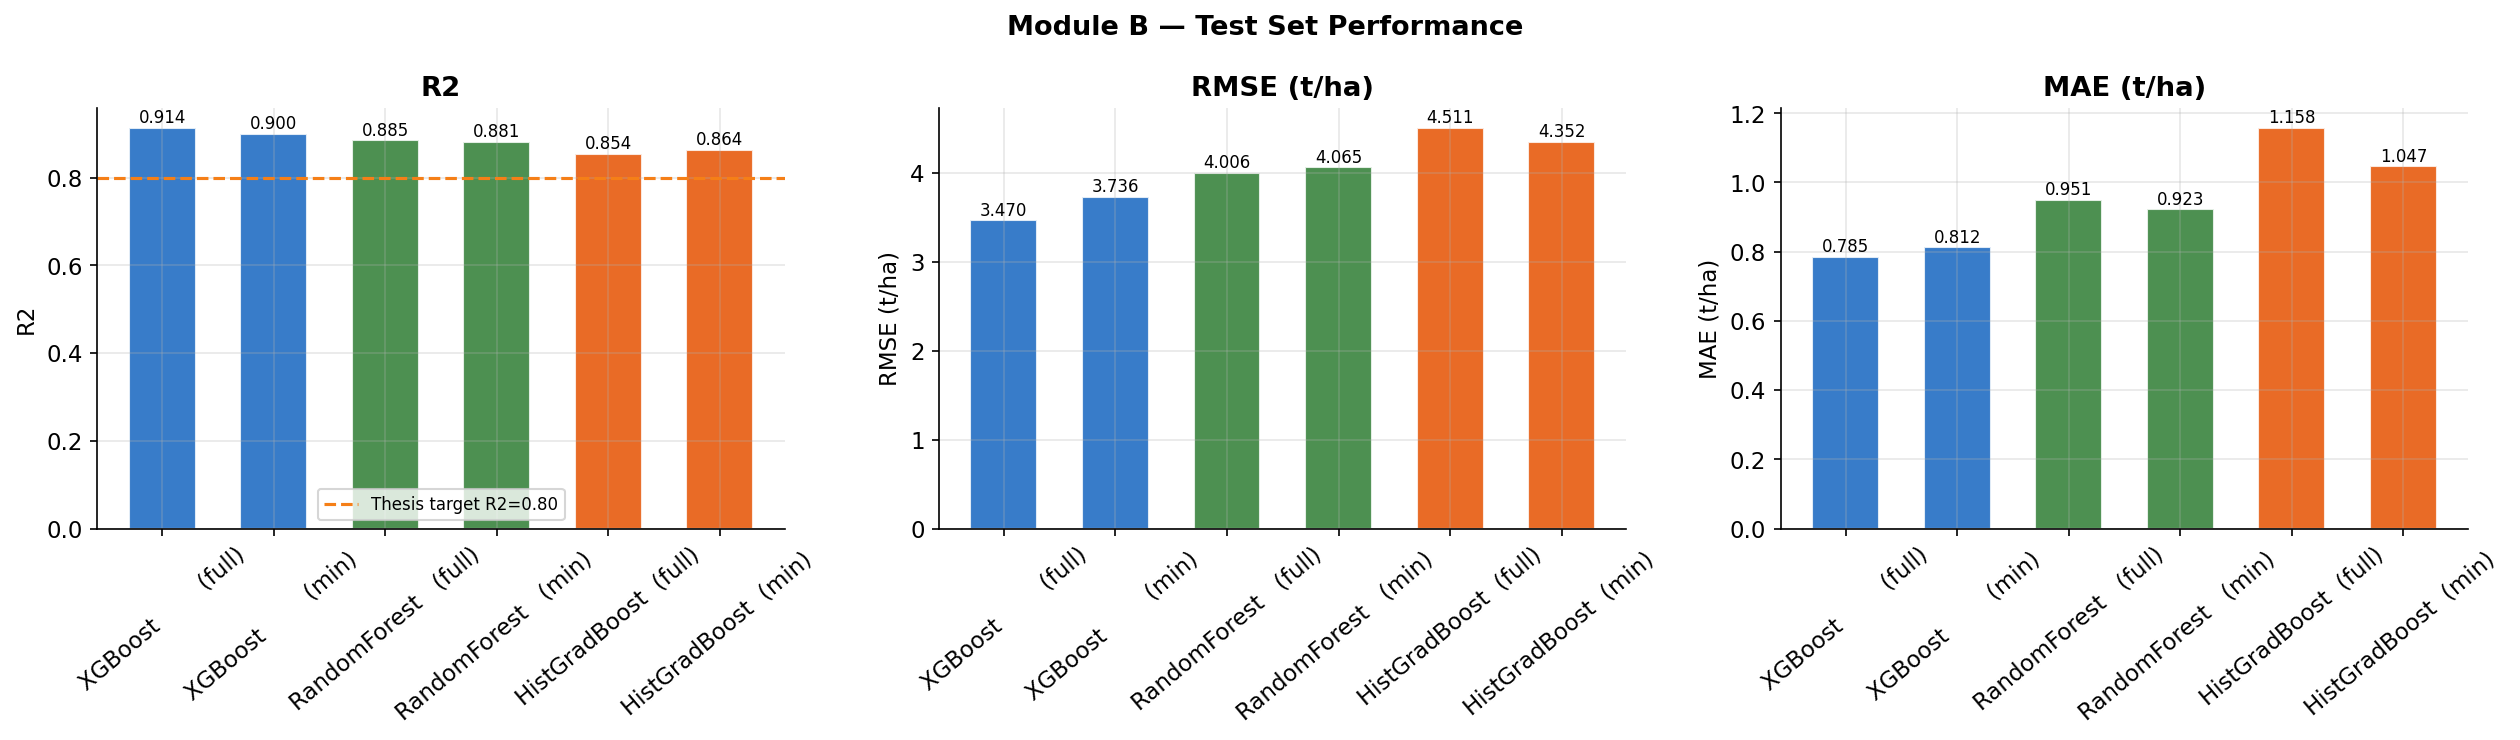

In [ ]:
# 7.1  Performance bar charts
bar_colors = [
    PALETTE['primary'], PALETTE['primary'],
    PALETTE['accent'],  PALETTE['accent'],
    PALETTE['secondary'], PALETTE['secondary'],
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['R2', 'RMSE (t/ha)', 'MAE (t/ha)']):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=bar_colors,
                  alpha=0.85, edgecolor='white', width=0.6)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=40)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002 * max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'R2':
        ax.axhline(0.80, color=PALETTE['warn'], linestyle='--',
                   linewidth=1.5, label='Thesis target R2=0.80')
        ax.legend(fontsize=8)

plt.suptitle('Module B \u2014 Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best model (full): XGBoost        (full)   R2=0.9137


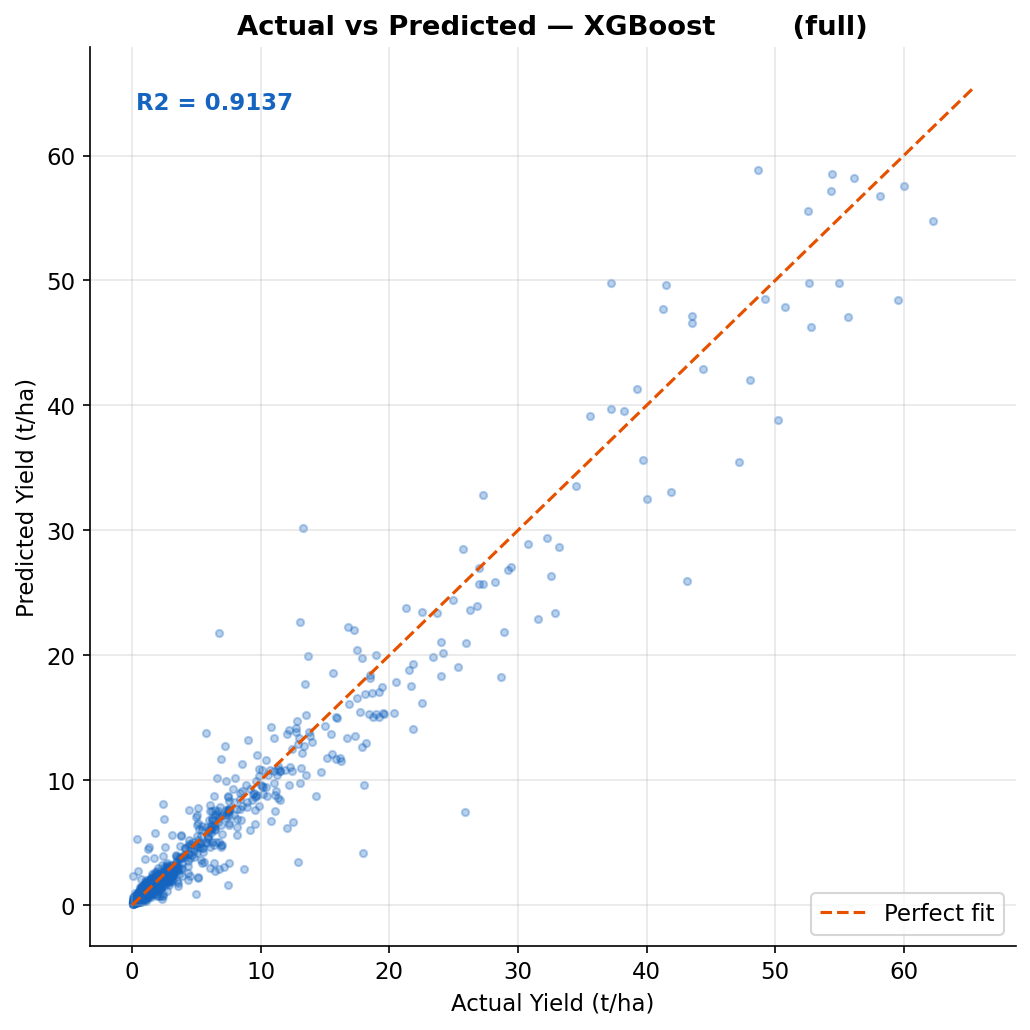

In [ ]:
# 7.2  Actual vs Predicted scatter (best full model)
best_row  = (results_df[results_df['Model'].str.contains('full')]
             .sort_values('R2', ascending=False).iloc[0])
best_name = best_row['Model'].strip()
print(f'Best model (full): {best_name}   R2={best_row["R2"]}')

model_map = {
    'XGBoost        (full)': (xgb_full, X_full_test_pp),
    'RandomForest   (full)': (rf_full,  X_full_test_pp),
    'HistGradBoost  (full)': (gb_full,  X_full_test_pp),
}
best_model, best_Xpp = model_map[best_name]

y_pred_best = np.clip(np.expm1(best_model.predict(best_Xpp)), 0, None)
y_true_best = y_test.values

clip_val = np.percentile(y_true_best, 99)
mask = (y_true_best <= clip_val) & (y_pred_best <= clip_val)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true_best[mask], y_pred_best[mask],
           alpha=0.3, s=12, color=PALETTE['primary'], rasterized=True)
lims = [0, clip_val]
ax.plot(lims, lims, color=PALETTE['secondary'], linewidth=1.5,
        linestyle='--', label='Perfect fit')
ax.set_title(f'Actual vs Predicted \u2014 {best_name}', fontweight='bold')
ax.set_xlabel('Actual Yield (t/ha)')
ax.set_ylabel('Predicted Yield (t/ha)')
ax.legend()
ax.text(0.05, 0.95, f'R2 = {best_row["R2"]:.4f}',
        transform=ax.transAxes, va='top', fontsize=11,
        color=PALETTE['primary'], fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
results_df.to_csv(os.path.join(ARTIFACT_ROOT, 'test_metrics.csv'), index=False)
with open(os.path.join(ARTIFACT_ROOT, 'best_model.json'), 'w') as f:
    json.dump({'best_full_model': best_name, 'r2': float(best_row['R2'])}, f, indent=2)
print(f'Checkpoint saved: {ARTIFACT_ROOT}/test_metrics.csv, {ARTIFACT_ROOT}/best_model.json')

Checkpoint saved: artifacts/yield/test_metrics.csv, artifacts/yield/best_model.json


### 8. SHAP Feature Importance Analysis

SHAP (SHapley Additive exPlanations) decomposes each model prediction into  
per-feature contributions using game-theoretic attribution.  
Applied to the best XGBoost model (full feature set) to answer RQ2:  
which inputs most consistently drive yield variance?

In [ ]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
print(f'SHAP {shap.__version__}')

SHAP 0.52.0


In [ ]:
# 8.1  Compute SHAP values
N_SHAP   = min(2000, X_full_test_pp.shape[0])
rng      = np.random.RandomState(RANDOM_STATE)
idx      = rng.choice(X_full_test_pp.shape[0], N_SHAP, replace=False)
X_shap   = X_full_test_pp[idx]

explainer   = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_shap)

# Reconstruct feature names
try:
    feat_names = preprocessor_full.get_feature_names_out().tolist()
except Exception:
    ohe        = preprocessor_full.named_transformers_['cat']['encoder']
    cat_names  = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    feat_names = NUMERIC_FEATURES_FULL + cat_names

print(f'SHAP computed on {N_SHAP} samples, {len(feat_names)} features.')

SHAP computed on 1958 samples, 96 features.


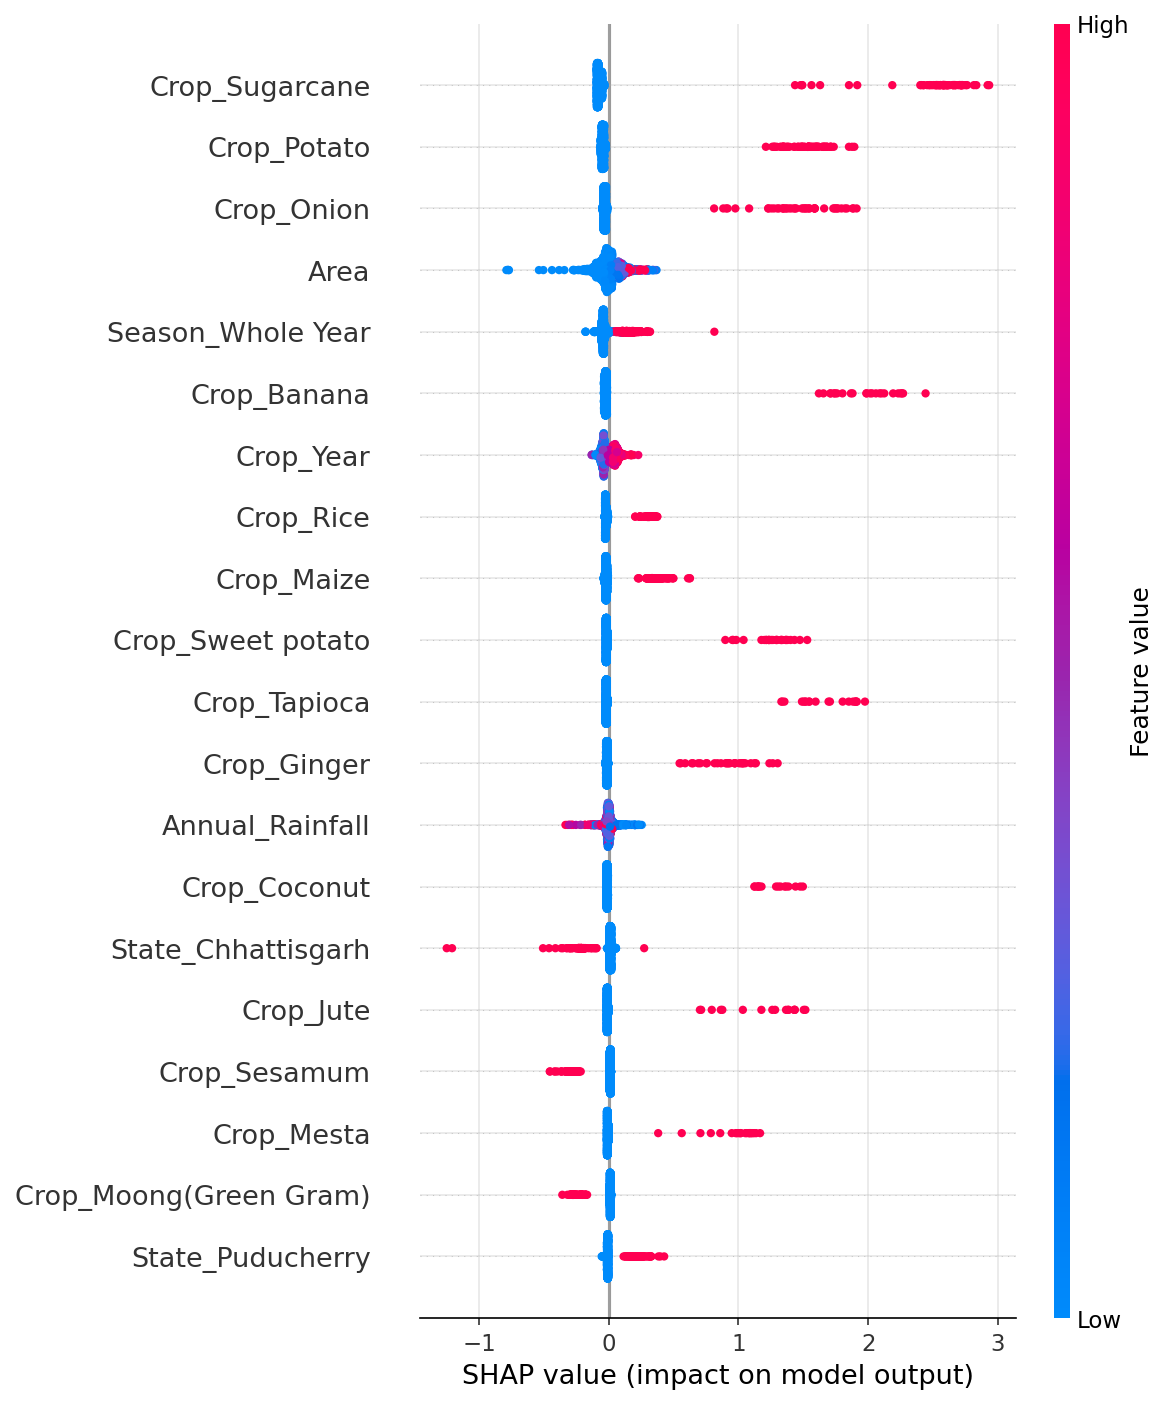

In [ ]:
# 8.2  Summary beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feat_names,
                  max_display=20, show=True, plot_type='dot')

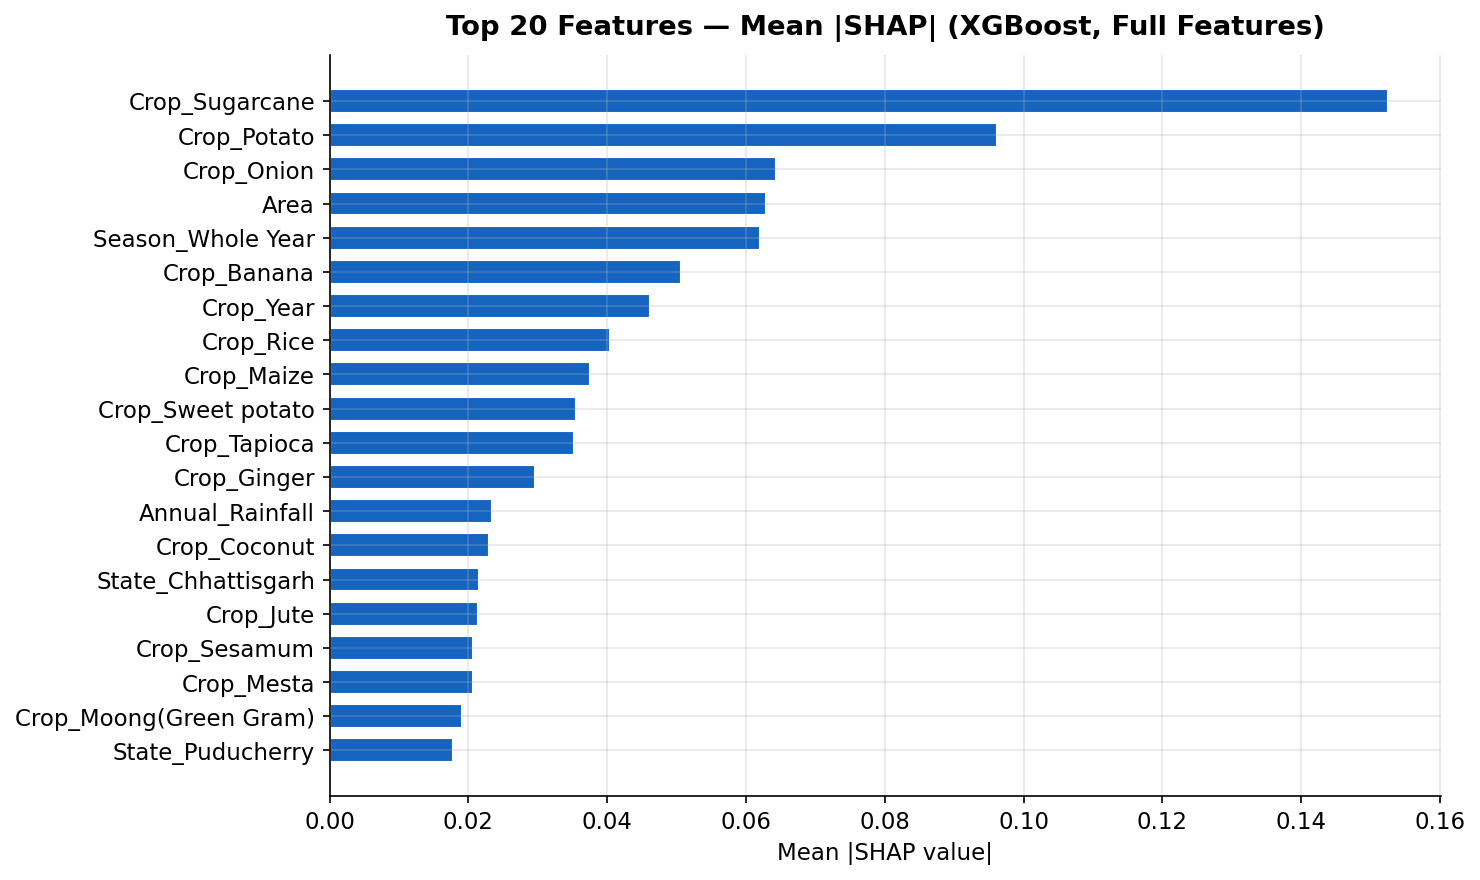


Top 10 features:
          Feature  Mean_SHAP
   Crop_Sugarcane   0.152550
      Crop_Potato   0.096137
       Crop_Onion   0.064346
             Area   0.062930
Season_Whole Year   0.062045
      Crop_Banana   0.050651
        Crop_Year   0.046149
        Crop_Rice   0.040357
       Crop_Maize   0.037561
Crop_Sweet potato   0.035524


In [ ]:
# 8.3  Mean |SHAP| bar chart (top 20)
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = (pd.DataFrame({'Feature': feat_names, 'Mean_SHAP': mean_shap})
             .sort_values('Mean_SHAP', ascending=False)
             .head(20).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shap_df['Feature'][::-1], shap_df['Mean_SHAP'][::-1],
        color=PALETTE['primary'], edgecolor='white', height=0.7)
ax.set_title('Top 20 Features \u2014 Mean |SHAP| (XGBoost, Full Features)',
             fontweight='bold', pad=10)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(shap_df.head(10).to_string(index=False))

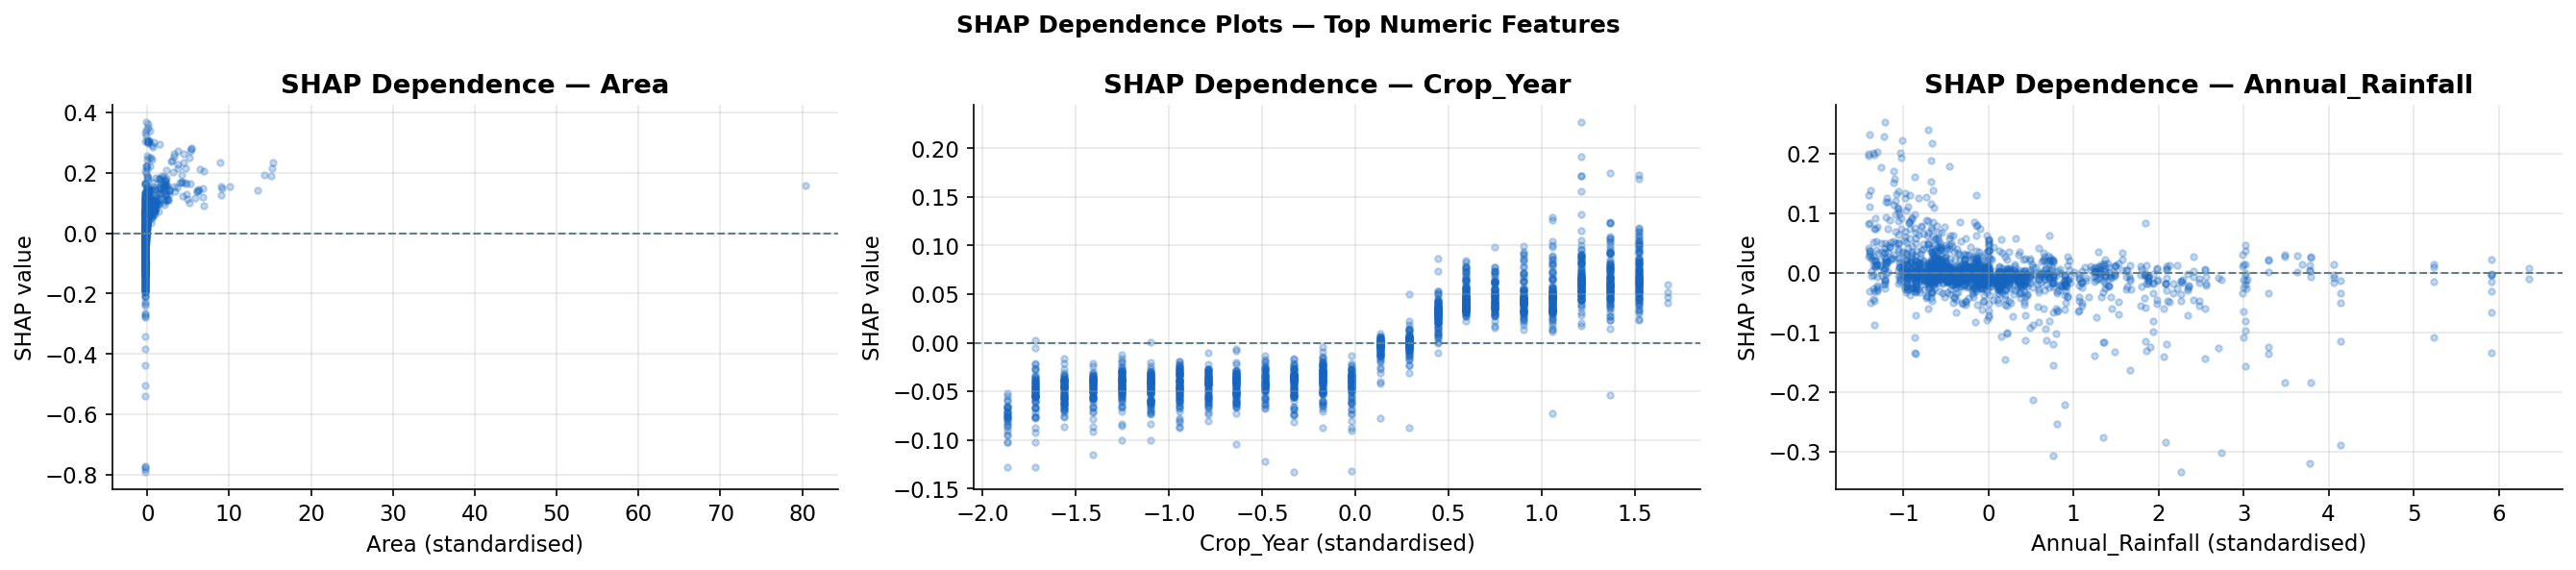

In [ ]:
# 8.4  SHAP dependence plots (top 3 numeric)
numeric_present = [f for f in NUMERIC_FEATURES_FULL if f in feat_names]
top3 = shap_df[shap_df['Feature'].isin(numeric_present)]['Feature'].head(3).tolist()

if top3:
    fig, axes = plt.subplots(1, len(top3), figsize=(6*len(top3), 4))
    if len(top3) == 1: axes = [axes]
    for ax, feat in zip(axes, top3):
        idx_f = feat_names.index(feat)
        ax.scatter(X_shap[:, idx_f], shap_values[:, idx_f],
                   alpha=0.25, s=10, color=PALETTE['primary'], rasterized=True)
        ax.axhline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--')
        ax.set_title(f'SHAP Dependence \u2014 {feat}', fontweight='bold')
        ax.set_xlabel(f'{feat} (standardised)')
        ax.set_ylabel('SHAP value')
    plt.suptitle('SHAP Dependence Plots \u2014 Top Numeric Features',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
shap_df.to_csv(os.path.join(ARTIFACT_ROOT, 'shap_feature_importance.csv'), index=False)
print(f'Checkpoint saved: {ARTIFACT_ROOT}/shap_feature_importance.csv')

Checkpoint saved: artifacts/yield/shap_feature_importance.csv


### 9. Ablation Study — Full vs Minimal Feature Set

Quantifies the marginal contribution of `Fertilizer_per_ha`, `Pesticide_per_ha`,  
and `Crop_Year` over the climate-only baseline (`Annual_Rainfall` + `Area`).  
Directly addresses the RQ2 sub-question on multi-feature contribution.

In [ ]:
# 9.1  Ablation table
ablation_records = []
for label, mf, Xf, mm, Xm in [
    ('XGBoost',      xgb_full, X_full_test_pp, xgb_min, X_min_test_pp),
    ('RandomForest', rf_full,  X_full_test_pp, rf_min,  X_min_test_pp),
    ('HistGradBoost',gb_full,  X_full_test_pp, gb_min,  X_min_test_pp),
]:
    rf = evaluate(mf, Xf, y_test, f'{label} (full)')
    rm = evaluate(mm, Xm, y_test, f'{label} (min)')
    ablation_records.append({
        'Model'           : label,
        'R2 Full'         : rf['R2'],
        'R2 Min'          : rm['R2'],
        'Delta R2'        : round(rf['R2'] - rm['R2'], 4),
        'RMSE Full (t/ha)': rf['RMSE (t/ha)'],
        'RMSE Min (t/ha)' : rm['RMSE (t/ha)'],
        'Delta RMSE'      : round(rm['RMSE (t/ha)'] - rf['RMSE (t/ha)'], 4),
    })

ablation_df = pd.DataFrame(ablation_records)
print('\u2550\u2550 ABLATION STUDY \u2014 Full vs Minimal \u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550')
print(ablation_df.to_string(index=False))

══ ABLATION STUDY — Full vs Minimal ═════════════════════
        Model  R2 Full  R2 Min  Delta R2  RMSE Full (t/ha)  RMSE Min (t/ha)  Delta RMSE
      XGBoost   0.9137  0.8999    0.0138            3.4695           3.7364      0.2669
 RandomForest   0.8849  0.8815    0.0034            4.0059           4.0647      0.0588
HistGradBoost   0.8540  0.8641   -0.0101            4.5111           4.3524     -0.1587


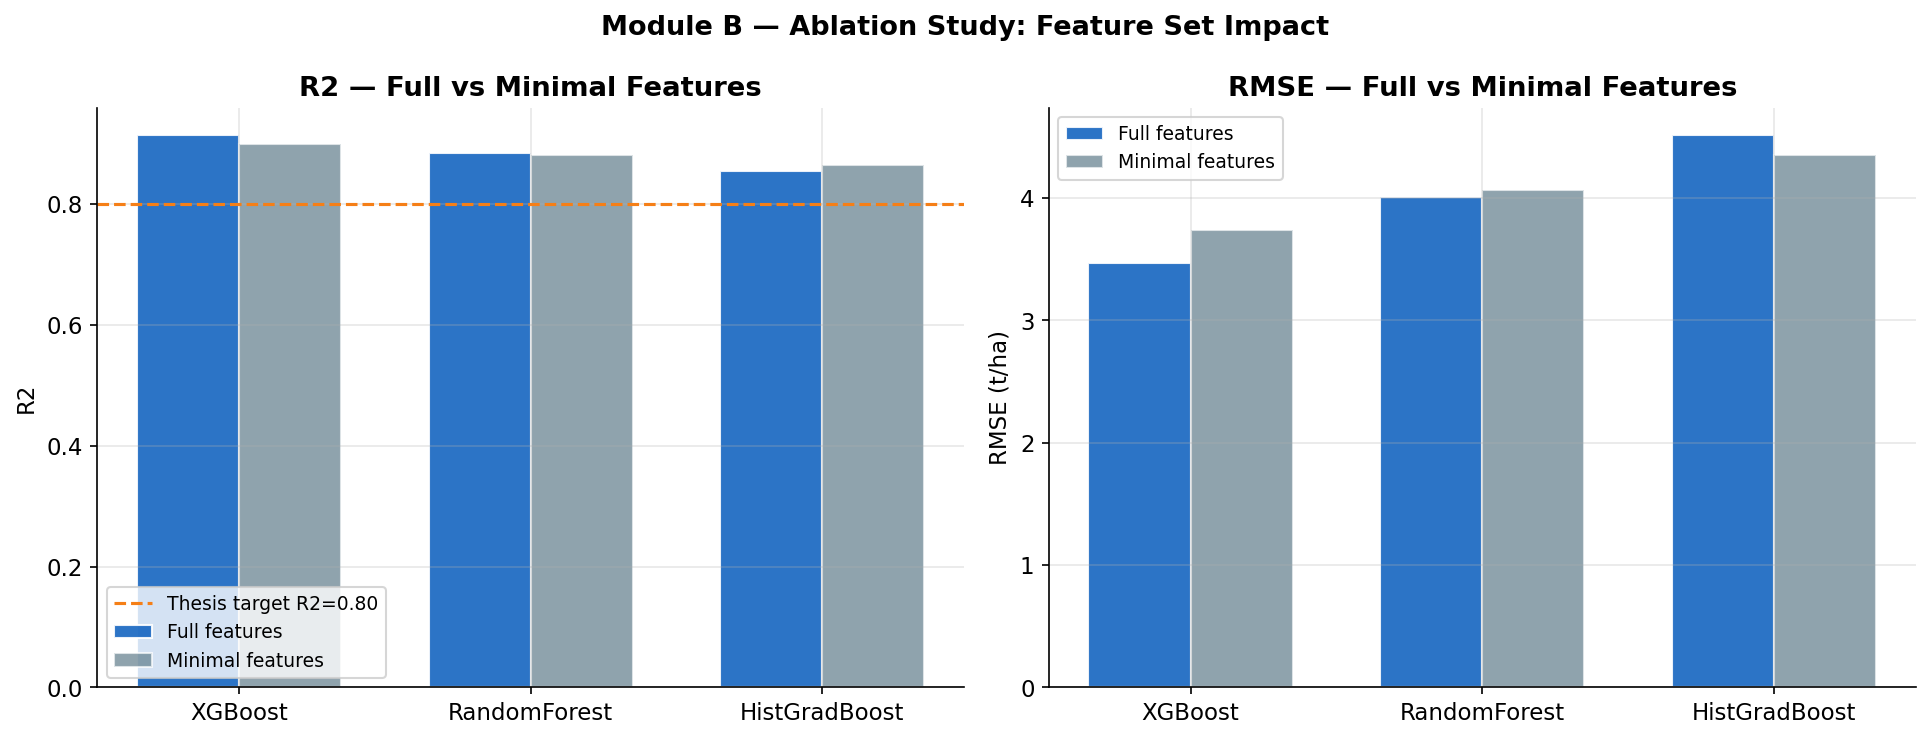

In [ ]:
# 9.2  Ablation visualisation
x, width = np.arange(len(ablation_df)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - width/2, ablation_df['R2 Full'], width,
            label='Full features', color=PALETTE['primary'], alpha=0.9, edgecolor='white')
axes[0].bar(x + width/2, ablation_df['R2 Min'],  width,
            label='Minimal features', color=PALETTE['neutral'], alpha=0.7, edgecolor='white')
axes[0].axhline(0.80, color=PALETTE['warn'], linestyle='--',
                linewidth=1.5, label='Thesis target R2=0.80')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ablation_df['Model'])
axes[0].set_title('R2 \u2014 Full vs Minimal Features', fontweight='bold')
axes[0].set_ylabel('R2')
axes[0].legend(fontsize=9)

axes[1].bar(x - width/2, ablation_df['RMSE Full (t/ha)'], width,
            label='Full features', color=PALETTE['primary'], alpha=0.9, edgecolor='white')
axes[1].bar(x + width/2, ablation_df['RMSE Min (t/ha)'],  width,
            label='Minimal features', color=PALETTE['neutral'], alpha=0.7, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ablation_df['Model'])
axes[1].set_title('RMSE \u2014 Full vs Minimal Features', fontweight='bold')
axes[1].set_ylabel('RMSE (t/ha)')
axes[1].legend(fontsize=9)

plt.suptitle('Module B \u2014 Ablation Study: Feature Set Impact',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
ablation_df.to_csv(os.path.join(ARTIFACT_ROOT, 'ablation_results.csv'), index=False)
print(f'Checkpoint saved: {ARTIFACT_ROOT}/ablation_results.csv')

Checkpoint saved: artifacts/yield/ablation_results.csv


### 10. Learning Curves

Train vs CV validation R² at increasing training set sizes.  
Confirms generalisation and checks for overfitting in the best model.


Computing learning curves ... (2–3 min)


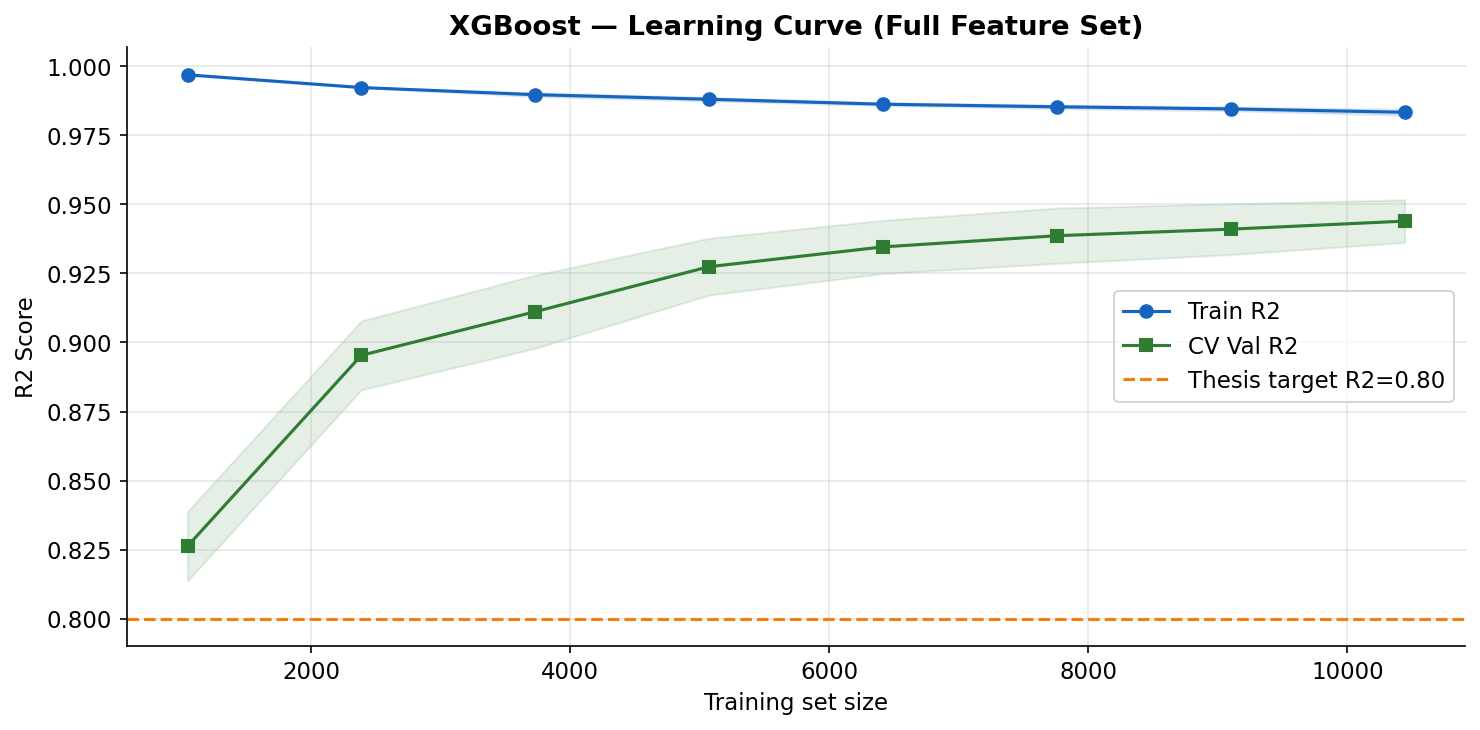

In [ ]:
print('Computing learning curves ... (2–3 min)')
train_sizes_frac = np.linspace(0.10, 1.0, 8)

train_sz, train_sc, val_sc = learning_curve(
    xgb.XGBRegressor(
        objective='reg:squarederror', random_state=RANDOM_STATE,
        tree_method='hist', device=DEVICE,
        subsample=0.8, colsample_bytree=0.8,
        **xgb_best_full),
    X_full_train_pp, y_train_log,
    train_sizes=train_sizes_frac,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sz, train_mean, 'o-', color=PALETTE['primary'], label='Train R2')
ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                alpha=0.12, color=PALETTE['primary'])
ax.plot(train_sz, val_mean, 's-', color=PALETTE['accent'], label='CV Val R2')
ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                alpha=0.12, color=PALETTE['accent'])
ax.axhline(0.80, color=PALETTE['warn'], linestyle='--',
           linewidth=1.5, label='Thesis target R2=0.80')
ax.set_xlabel('Training set size')
ax.set_ylabel('R2 Score')
ax.set_title('XGBoost \u2014 Learning Curve (Full Feature Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 11. Module B — Final Summary

In [ ]:
divider = '=' * 60
print(divider)
print('  MODULE B \u2014 CROP YIELD PREDICTION \u2014 FINAL SUMMARY')
print(divider)

best_full = (results_df[results_df['Model'].str.contains('full')]
             .sort_values('R2', ascending=False).iloc[0])
best_min  = (results_df[results_df['Model'].str.contains('min')]
             .sort_values('R2', ascending=False).iloc[0])

print(f'\n  Dataset')
print(f'    Records          : {len(df):,}')
print(f'    Crops            : {df["Crop"].nunique()}')
print(f'    States           : {df["State"].nunique()}')
print(f'    Year range       : {df["Crop_Year"].min()} \u2013 {df["Crop_Year"].max()}')

print(f'\n  Best model (full features)')
print(f'    Model            : {best_full["Model"].strip()}')
print(f'    R2               : {best_full["R2"]}   (thesis target >= 0.80)')
print(f'    RMSE             : {best_full["RMSE (t/ha)"]} t/ha')
print(f'    MAE              : {best_full["MAE (t/ha)"]} t/ha')

print(f'\n  Best model (minimal features)')
print(f'    Model            : {best_min["Model"].strip()}')
print(f'    R2               : {best_min["R2"]}')
print(f'    RMSE             : {best_min["RMSE (t/ha)"]} t/ha')

best_algo = best_full['Model'].split('(')[0].strip()
ab_row = ablation_df[ablation_df['Model'].str.contains(
    best_algo.replace('HistGradBoost','HistGradBoost')
             .replace('RandomForest','RandomForest')
             .replace('XGBoost','XGBoost'))]
if not ab_row.empty:
    print(f'\n  Ablation delta R2 (full - min): {ab_row.iloc[0]["Delta R2"]:+.4f}')

print(f'  Top SHAP feature           : {shap_df.iloc[0]["Feature"]}')

rq2_met = best_full['R2'] >= 0.80
status  = '\u2713 YES' if rq2_met else '\u2717 NO \u2014 consider feature engineering or stacking'
print(f'\n  RQ2 target (R2 >= 0.80) met: {status}')

print('\n  All models, metrics, SHAP and ablation analyses complete.')
print('  Module B ready for dissertation write-up.')
print(divider)

  MODULE B — CROP YIELD PREDICTION — FINAL SUMMARY

  Dataset
    Records          : 19,577
    Crops            : 55
    States           : 30
    Year range       : 1997 – 2020

  Best model (full features)
    Model            : XGBoost        (full)
    R2               : 0.9137   (thesis target >= 0.80)
    RMSE             : 3.4695 t/ha
    MAE              : 0.7846 t/ha

  Best model (minimal features)
    Model            : XGBoost        (min)
    R2               : 0.8999
    RMSE             : 3.7364 t/ha

  Ablation delta R2 (full - min): +0.0138
  Top SHAP feature           : Crop_Sugarcane

  RQ2 target (R2 >= 0.80) met: ✓ YES

  All models, metrics, SHAP and ablation analyses complete.
  Module B ready for dissertation write-up.


In [ ]:
import datetime

manifest = {
    'generated_at': datetime.datetime.now().isoformat(),
    'artifact_root': ARTIFACT_ROOT,
    'files': sorted(
        os.path.relpath(os.path.join(dp, fn), ARTIFACT_ROOT)
        for dp, _, fnames in os.walk(ARTIFACT_ROOT) for fn in fnames
    ),
    'best_full_feature_model': best_name,
    'best_full_feature_r2': float(best_row['R2']),
    'rq2_target_met': bool(rq2_met),
}
with open(os.path.join(ARTIFACT_ROOT, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'\nManifest written: {ARTIFACT_ROOT}/manifest.json')
print(f'Total artifact files: {len(manifest["files"])}')
for fn in manifest['files']:
    print(' -', fn)

# Optional: zip the whole artifact folder for download / committing to the backend repo
try:
    from google.colab import files
    shutil.make_archive('yield_artifacts', 'zip', ARTIFACT_ROOT)
    print("\nZipped to yield_artifacts.zip — downloading...")
    files.download('yield_artifacts.zip')
except ModuleNotFoundError:
    print(f"\nLocal Jupyter: artifacts are already on disk at {os.path.abspath(ARTIFACT_ROOT)}")


Manifest written: artifacts/yield/manifest.json
Total artifact files: 18
 - ablation_results.csv
 - best_model.json
 - best_params.json
 - cleaned_dataset.csv
 - feature_config.json
 - models/gb_full.pkl
 - models/gb_min.pkl
 - models/rf_full.pkl
 - models/rf_min.pkl
 - models/xgb_full.pkl
 - models/xgb_min.pkl
 - preprocessor_full.pkl
 - preprocessor_min.pkl
 - shap_feature_importance.csv
 - test_metrics.csv
 - test_split.csv
 - train_split.csv
 - val_split.csv

Zipped to yield_artifacts.zip — downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>